# <a id='toc1_'></a>[Digital signal processing. Lab3](#toc0_)

In [9]:
%%capture 
%pip install matplotlib 
%pip install numpy
%pip install scipy

**Table of contents**<a id='toc0_'></a>    
- [Digital signal processing. Lab3](#toc1_)    
  - [Task1](#toc1_1_)    
  - [Task2](#toc1_2_)    
  - [Task3](#toc1_3_)    
  - [Task4](#toc1_4_)    
    - [Task4(a)](#toc1_4_1_)    
    - [Task4(b)](#toc1_4_2_)    
  - [Task5](#toc1_5_)    
  - [Task6](#toc1_6_)    
  - [Task7](#toc1_7_)    
  - [Task8](#toc1_8_)    
  - [Task9](#toc1_9_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Task1](#toc0_)
На вход передатчика подается сигнал косинуса с частотами 50, 150 и 450 Гц. Определите спектр сигнала с помощью стандартной функции быстрого преобразования Фурье (FFT).

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

In [11]:
f_1 = 50.0
f_2 = 150.0
f_3 = 450.0

Fs = 2000 
dt = 1.0 / Fs

w_1 = 2 * np.pi * f_1
w_2 = 2 * np.pi * f_2
w_3 = 2 * np.pi * f_3

signal = lambda t : np.cos(w_1 * t) + np.cos(w_2 * t) + np.cos(w_3 * t)

In [12]:
t_vals = np.arange(0, 1, dt)
signal_vals = signal(t_vals)

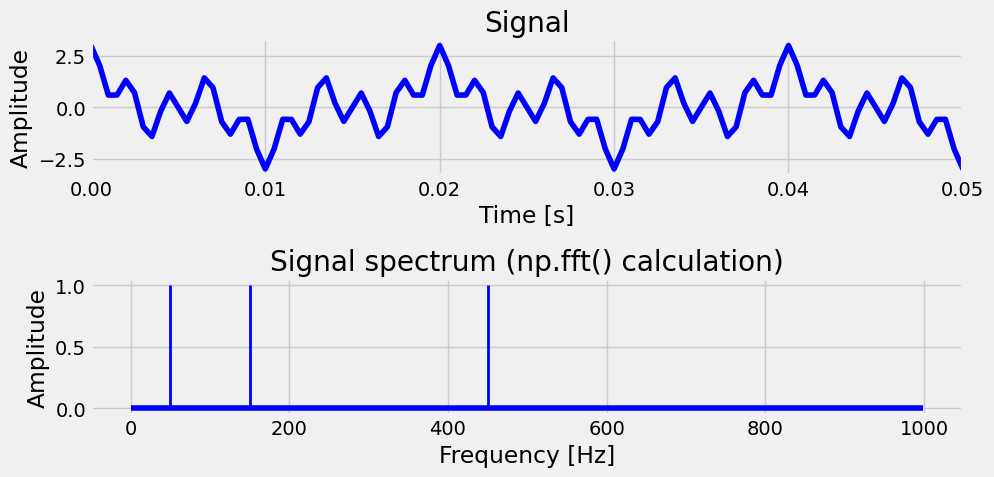

In [13]:
spectrum_fft = np.fft.fft(signal_vals)

N = signal_vals.shape[-1]

freq = np.fft.fftfreq(N, dt)

plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
plt.plot(t_vals, signal_vals, 'b')
plt.title('Signal')
plt.xlabel('Time [s]')
plt.xlim(0, 0.05)
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(spectrum_fft[:N//2]))
plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')
plt.title('Signal spectrum (np.fft() calculation)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

## <a id='toc1_2_'></a>[Task2](#toc0_)
Реализовать алгоритм фильтра Баттерворта нижних частот 2-го порядка (ФНЧ) к сигналу из пункта 1, убедиться, что происходит подавление высоких частот сигнала 150 и 450 Гц. 
* При моделировании ФНЧ воспользоваться формулой (32) из методички «Козулин Меркулова Применение Python для ЦОС.pdf». 
* Частоту среза фильтра Баттерворта подберите самостоятельно (в диапазоне от 70 до 120 Гц).
* Построить графики исходного и отфильтрованного сигнала, спектра сигнала и спектр фильтра Баттерворта. 
* Убедитесь, что амплитуда исходного сигнала для частоты 50 Гц совпадает с амплитудой отфильтрованного сигнала.

In [14]:
fc = np.arange(70,121,10)
wc = 2 * np.pi * fc
numb_filter = fc.shape[0]

w = freq.copy() * 2 * np.pi

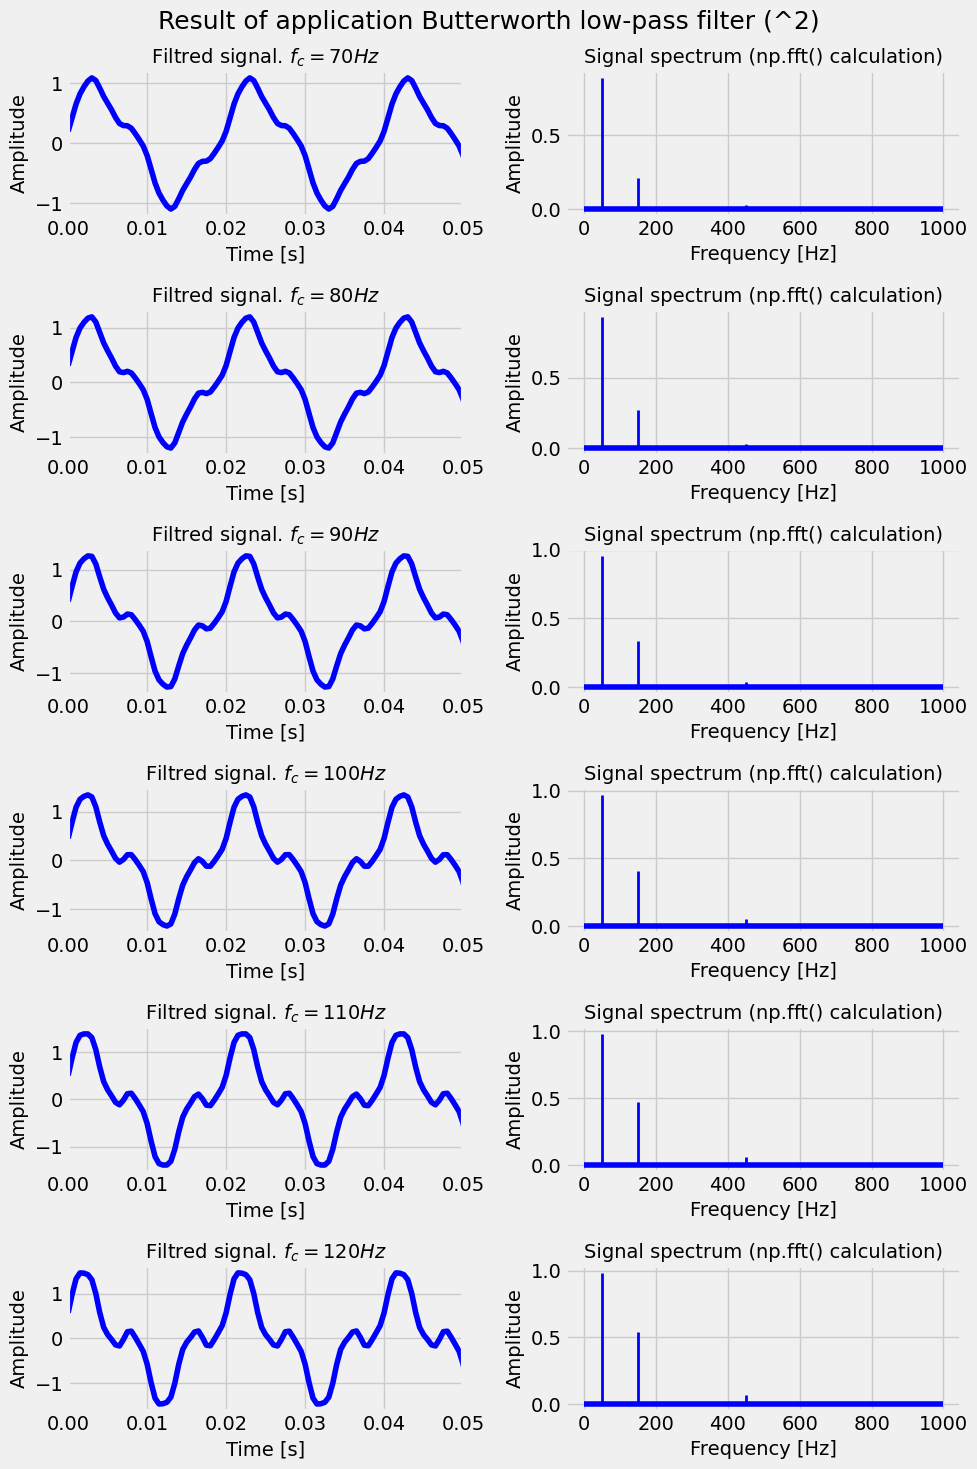

In [15]:
plt.figure(figsize=(10, 2.5 * numb_filter))
plt.suptitle('Result of application Butterworth low-pass filter (^2)', fontsize=18)

for i in range (numb_filter):
    H =  (wc[i]**2) / (-(w**2) + 1j * np.sqrt(2) * wc[i] * w + wc[i]**2)
    
    filtered_spectrum = H * spectrum_fft
    N = filtered_spectrum.shape[0]

    filtered_signal = np.fft.ifft(filtered_spectrum).real

    plt.subplot(numb_filter, 2, 2 * i + 1)
    plt.plot(t_vals, filtered_signal, 'b')
    plt.title(f'Filtred signal. $f_c ={fc[i]} Hz$', fontsize=14)
    plt.xlabel('Time [s]', fontsize=14)
    plt.xlim(0, 0.05)
    plt.ylabel('Amplitude', fontsize=14)

    plt.subplot(numb_filter, 2, 2 * i + 2)
    markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(filtered_spectrum[:N//2]))

    plt.setp(stemlines, color='blue', linewidth=2) 
    plt.setp(markerline, color='red', markersize=0)
    plt.setp(baseline, color='blue')

    plt.title('Signal spectrum (np.fft() calculation)', fontsize=14)
    plt.xlabel('Frequency [Hz]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.tight_layout()
plt.show()

## <a id='toc1_3_'></a>[Task3](#toc0_)
Построить фильтр высоких частот (ФВЧ) к сигналу, убедиться, что происходит подавление низких частот сигнала (50 и 150 Гц), воспользовавшись формулой (35) из методички «Козулин Цифровая обработка сигналов Python.pdf». 
* Построить графики исходного и отфильтрованного сигнала, спектра сигнала и фильтра ФНЧ.

In [16]:
fc = np.arange(100, 301, 50)
wc = 2 * np.pi * fc
numb_filter = fc.shape[0]

w = freq.copy() * 2 * np.pi

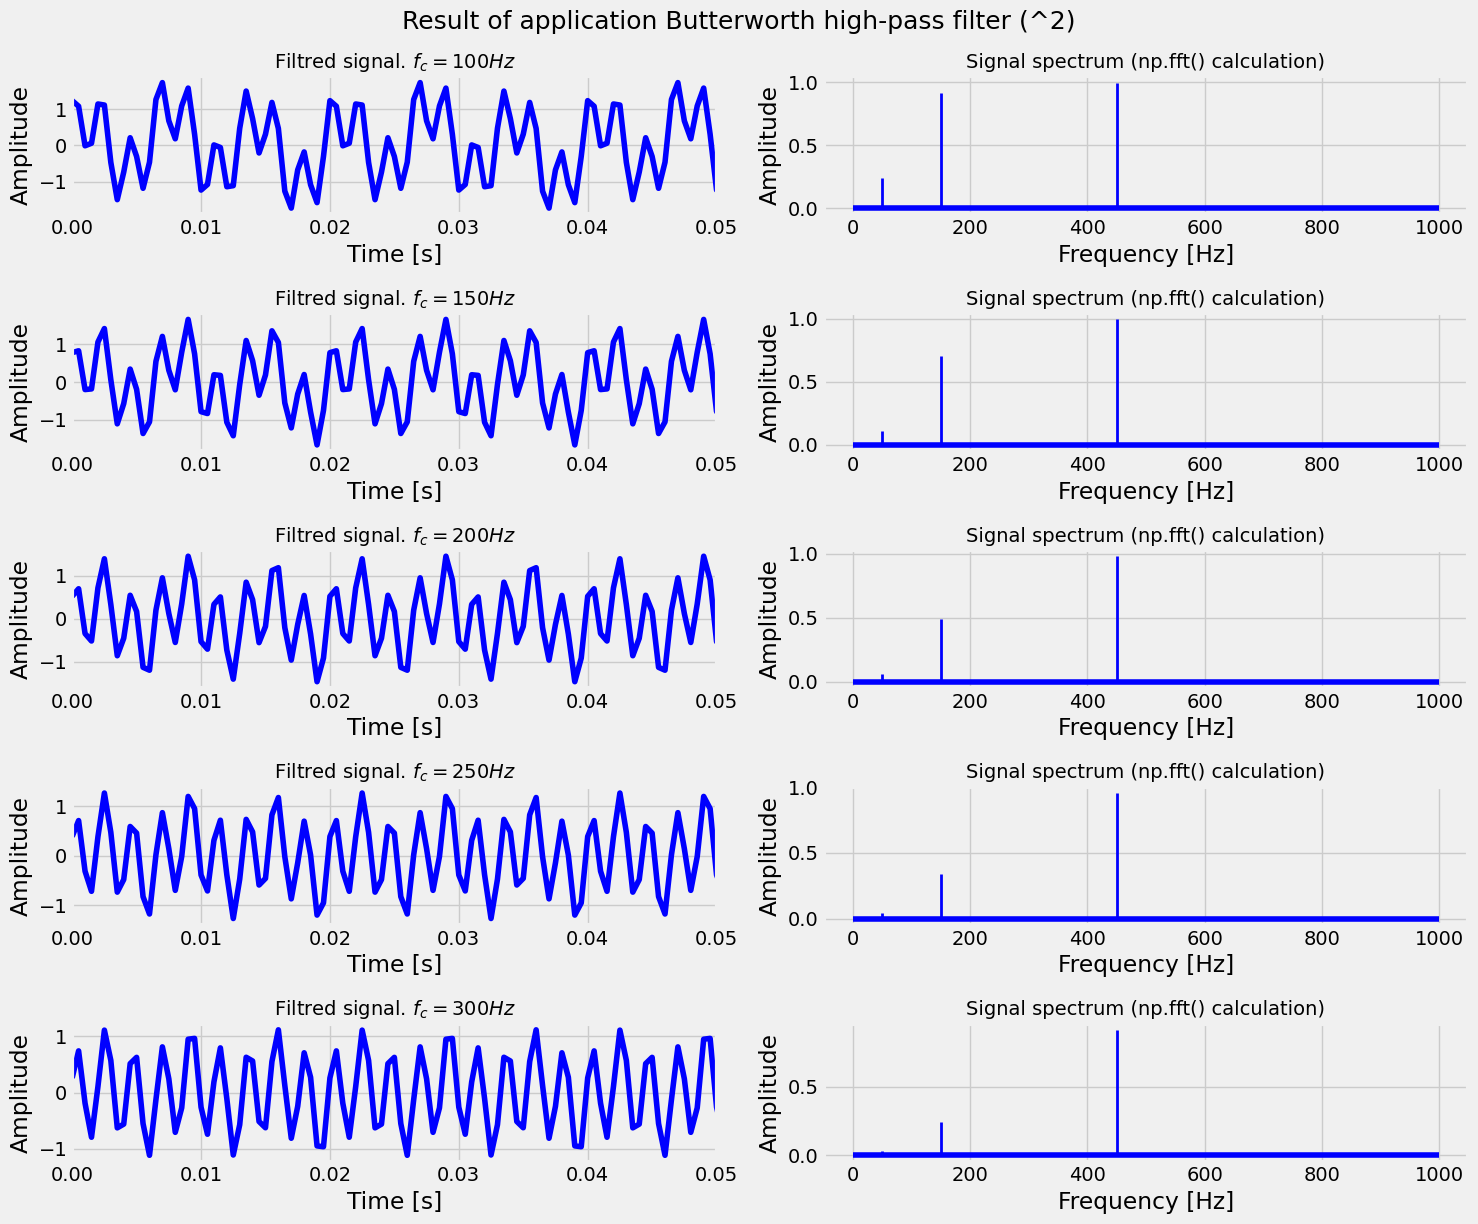

In [17]:
plt.figure(figsize=(15, 2.5 * numb_filter))
plt.suptitle('Result of application Butterworth high-pass filter (^2)', fontsize=18)

for i in range (numb_filter):
    H =  (w**2) / (-(wc[i]**2) + 1j * np.sqrt(2) * wc[i] * w + w**2)
    
    filtered_spectrum = H * spectrum_fft
    N = filtered_spectrum.shape[0]

    filtered_signal = np.fft.ifft(filtered_spectrum).real

    plt.subplot(numb_filter, 2, 2 * i + 1)
    plt.plot(t_vals, filtered_signal, 'b')
    plt.title(f'Filtred signal. $f_c ={fc[i]} Hz$', fontsize=14)
    plt.xlabel('Time [s]')
    plt.xlim(0, 0.05)
    plt.ylabel('Amplitude')

    plt.subplot(numb_filter, 2, 2 * i + 2)
    markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(filtered_spectrum[:N//2]))

    plt.setp(stemlines, color='blue', linewidth=2) 
    plt.setp(markerline, color='red', markersize=0)
    plt.setp(baseline, color='blue')

    plt.title('Signal spectrum (np.fft() calculation)', fontsize=14)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Amplitude')
    plt.tight_layout()
plt.show()

## <a id='toc1_4_'></a>[Task4](#toc0_)
Построить 
 * **(a)** полосовой фильтр (*формула 36*);
 * **(b)** заграждающий фильтр (*формула 38*).
 
*настроенные на частоту 150 Гц.* 

* Построить графики исходного и отфильтрованного сигнала, спектра сигнала и фильтров ПФ/ЗФ.

### <a id='toc1_4_1_'></a>[Task4(a)](#toc0_)

In [18]:
fc_l = fc_h = 150 # l/h - low/high frequencies forming a window (frequencies included in it will be missed)
wc_l = 2 * np.pi * fc_l
wc_h = 2 * np.pi * fc_h

w = freq.copy() * 2 * np.pi

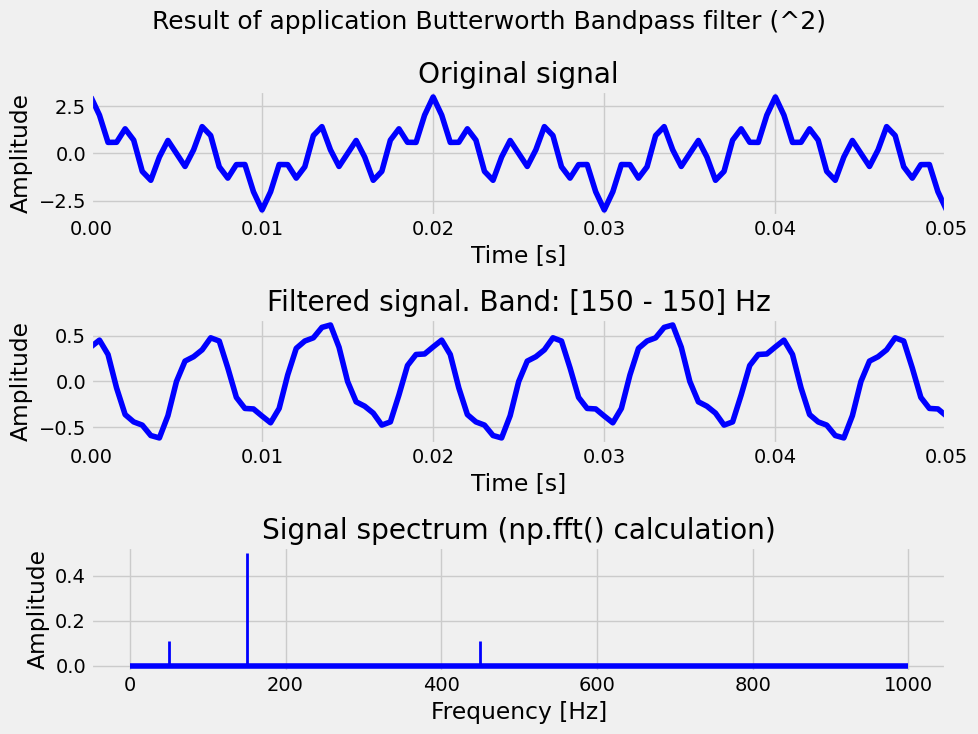

In [19]:
H_lpf = wc_l**2 / ((1j*w)**2 + np.sqrt(2)*wc_l*(1j*w) + wc_l**2)
H_hpf = (1j*w)**2 / ((1j*w)**2 + np.sqrt(2)*wc_h*(1j*w) + wc_h**2)


H = H_lpf * H_hpf
    
filtered_spectrum = H * spectrum_fft
N = filtered_spectrum.shape[0]

filtered_signal = np.fft.ifft(filtered_spectrum).real

plt.figure(figsize=(10, 7.5))
plt.suptitle('Result of application Butterworth Bandpass filter (^2)', fontsize=18)

plt.subplot(3, 1, 1)
plt.plot(t_vals, signal_vals, 'b')
plt.title('Original signal')
plt.xlabel('Time [s]')
plt.xlim(0, 0.05)
plt.ylabel('Amplitude')

plt.subplot(3, 1, 2)
plt.plot(t_vals, filtered_signal, 'b')
plt.title(f'Filtered signal. Band: [{fc_l} - {fc_h}] Hz')
plt.xlabel('Time [s]')
plt.xlim(0, 0.05)
plt.ylabel('Amplitude')

plt.subplot(3, 1, 3)
markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(filtered_spectrum[:N//2]))
plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Signal spectrum (np.fft() calculation)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

### <a id='toc1_4_2_'></a>[Task4(b)](#toc0_)

In [20]:
main_axis = 150 # l/h - low/high frequencies forming a window (frequencies included in it will be detained)

delta = 25
fc_l = main_axis - delta
fc_h = main_axis + delta 

wc_l = 2 * np.pi * fc_l
wc_h = 2 * np.pi * fc_h

w = freq.copy() * 2 * np.pi

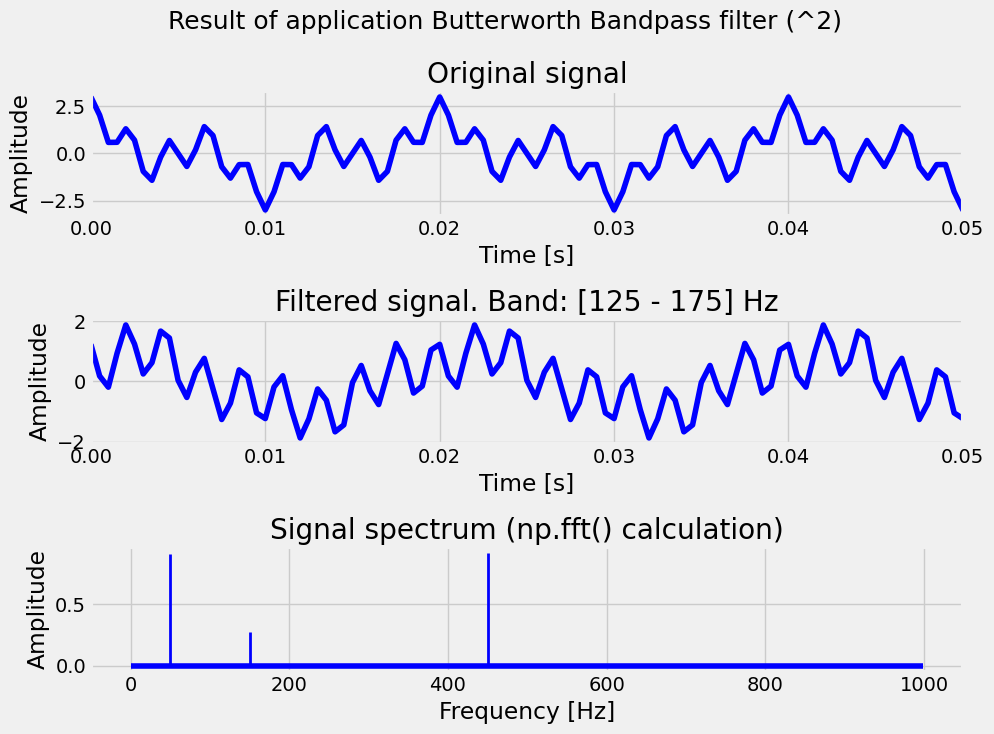

In [21]:
H_lpf = wc_l**2 / ((1j*w)**2 + np.sqrt(2)*wc_l*(1j*w) + wc_l**2)
H_hpf = (1j*w)**2 / ((1j*w)**2 + np.sqrt(2)*wc_h*(1j*w) + wc_h**2)

H = H_lpf + H_hpf
    
filtered_spectrum = H * spectrum_fft
N = filtered_spectrum.shape[0]

filtered_signal = np.fft.ifft(filtered_spectrum).real

plt.figure(figsize=(10, 7.5))
plt.suptitle('Result of application Butterworth Bandpass filter (^2)', fontsize=18)

plt.subplot(3, 1, 1)
plt.plot(t_vals, signal_vals, 'b')
plt.title('Original signal')
plt.xlabel('Time [s]')
plt.xlim(0, 0.05)
plt.ylabel('Amplitude')

plt.subplot(3, 1, 2)
plt.plot(t_vals, filtered_signal, 'b')
plt.title(f'Filtered signal. Band: [{fc_l} - {fc_h}] Hz')
plt.xlabel('Time [s]')
plt.xlim(0, 0.05)
plt.ylabel('Amplitude')

plt.subplot(3, 1, 3)
markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(filtered_spectrum[:N//2]))
plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Signal spectrum (np.fft() calculation)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

## <a id='toc1_5_'></a>[Task5](#toc0_)
Согласно формулам (28, 29) возможно построить фильтр Баттерворта любого порядка. 
* Постройте фильтр Баттерворта 4-го и 5-го порядка с автоматическим определением полюсов фильтра. 
* Реализуйте пункт 1 данной лабораторной для фильтра Баттерворта 5-го порядка.
* *Примечание:* Физически реализуемому фильтру отвечают только полюсы, расположенные в левой полуплоскости.

In [22]:
poles_4 = [np.exp(1j * (np.pi/2 + (2*k + 1)*np.pi/(2*4))) for k in range(2*4)]
poles_5 = [np.exp(1j * (np.pi/2 + (2*k + 1)*np.pi/(2*5))) for k in range(2*5)]

poles_4_left = list(filter(lambda p: np.real(p) < 0, poles_4))
poles_5_left = list(filter(lambda p: np.real(p) < 0, poles_5))

In [23]:
den_4 = np.poly(poles_4_left)
den_5 = np.poly(poles_5_left)

In [24]:
fc = np.arange(70,121,10)
wc = 2 * np.pi * fc
numb_filter = fc.shape[0]

In [25]:
w = freq.copy() * 2 * np.pi
S = [1j * w / wc_i for wc_i in wc]


In [26]:
H_4 = 1 / np.polyval(den_4, S)
H_5 = 1 / np.polyval(den_5, S)

H_5

array([[1.        +6.66133815e-16j, 0.99893155-4.62142776e-02j,
        0.99572782-9.23369801e-02j, ..., 0.99039365+1.38276604e-01j,
        0.99572782+9.23369801e-02j, 0.99893155+4.62142776e-02j],
       [1.        +6.66133815e-16j, 0.99918194-4.04406233e-02j,
        0.99672872-8.08198956e-02j, ..., 0.99264318+1.21076503e-01j,
        0.99672872+8.08198956e-02j, 0.99918194+4.04406233e-02j],
       [1.        +6.66133815e-16j, 0.99935362-3.59491285e-02j,
        0.99741508-7.18551669e-02j, ..., 0.99418614+1.07675045e-01j,
        0.99741508+7.18551669e-02j, 0.99935362+3.59491285e-02j],
       [1.        +6.66133815e-16j, 0.99947643-3.23554438e-02j,
        0.99790609-6.46794742e-02j, ..., 0.99529016+9.69406898e-02j,
        0.99790609+6.46794742e-02j, 0.99947643+3.23554438e-02j],
       [1.        +6.66133815e-16j, 0.99956729-2.94148659e-02j,
        0.99826942-5.88061301e-02j, ..., 0.99610719+8.81501982e-02j,
        0.99826942+5.88061301e-02j, 0.99956729+2.94148659e-02j],
       [1.

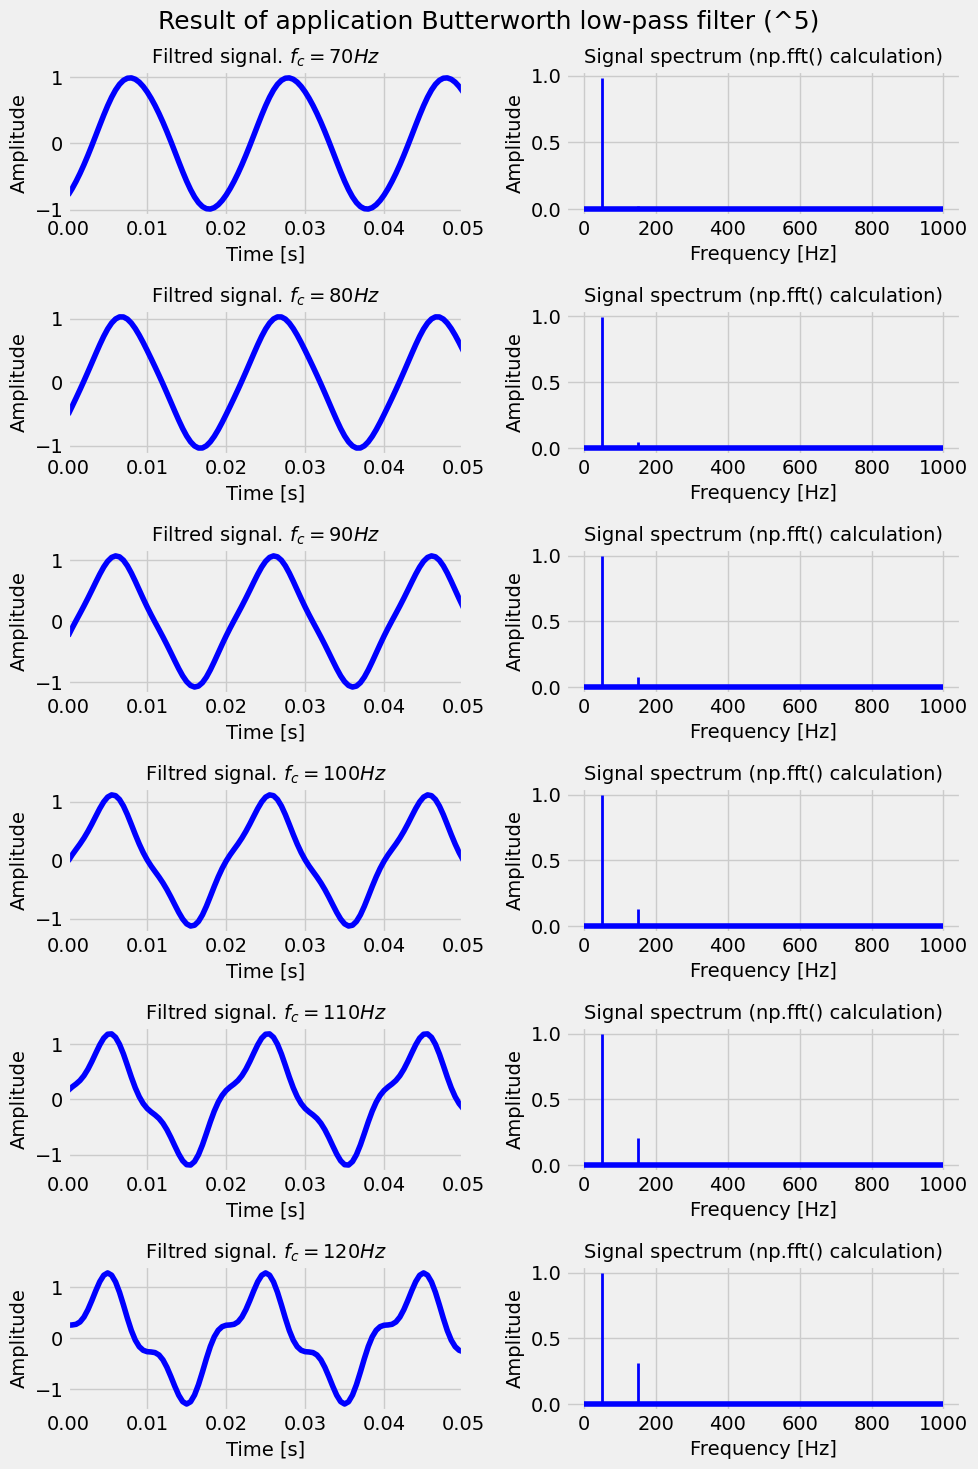

In [27]:
plt.figure(figsize=(10, 2.5 * numb_filter))
plt.suptitle('Result of application Butterworth low-pass filter (^5)', fontsize=18)

for i in range (numb_filter):
    filtered_spectrum = H_5[i] * spectrum_fft
    N = filtered_spectrum.shape[0]

    filtered_signal = np.fft.ifft(filtered_spectrum).real

    plt.subplot(numb_filter, 2, 2 * i + 1)
    plt.plot(t_vals, filtered_signal, 'b')
    plt.title(f'Filtred signal. $f_c ={fc[i]} Hz$', fontsize=14)
    plt.xlabel('Time [s]', fontsize=14)
    plt.xlim(0, 0.05)
    plt.ylabel('Amplitude', fontsize=14)

    plt.subplot(numb_filter, 2, 2 * i + 2)
    markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(filtered_spectrum[:N//2]))

    plt.setp(stemlines, color='blue', linewidth=2) 
    plt.setp(markerline, color='red', markersize=0)
    plt.setp(baseline, color='blue')

    plt.title('Signal spectrum (np.fft() calculation)', fontsize=14)
    plt.xlabel('Frequency [Hz]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.tight_layout()
plt.show()

## <a id='toc1_6_'></a>[Task6](#toc0_)
Сравните реализованный Вами фильтр 5-го порядка с фильтром 2-го порядка, объясните разницу в крутизне среза и фазовых характеристиках.

## <a id='toc1_7_'></a>[Task7](#toc0_)
Сравните Ваш алгоритм ФНЧ Баттерворта 5-го порядка с встроенным фильтром Баттерворта библиотеки `scipy.signal` также для 5-го порядка.

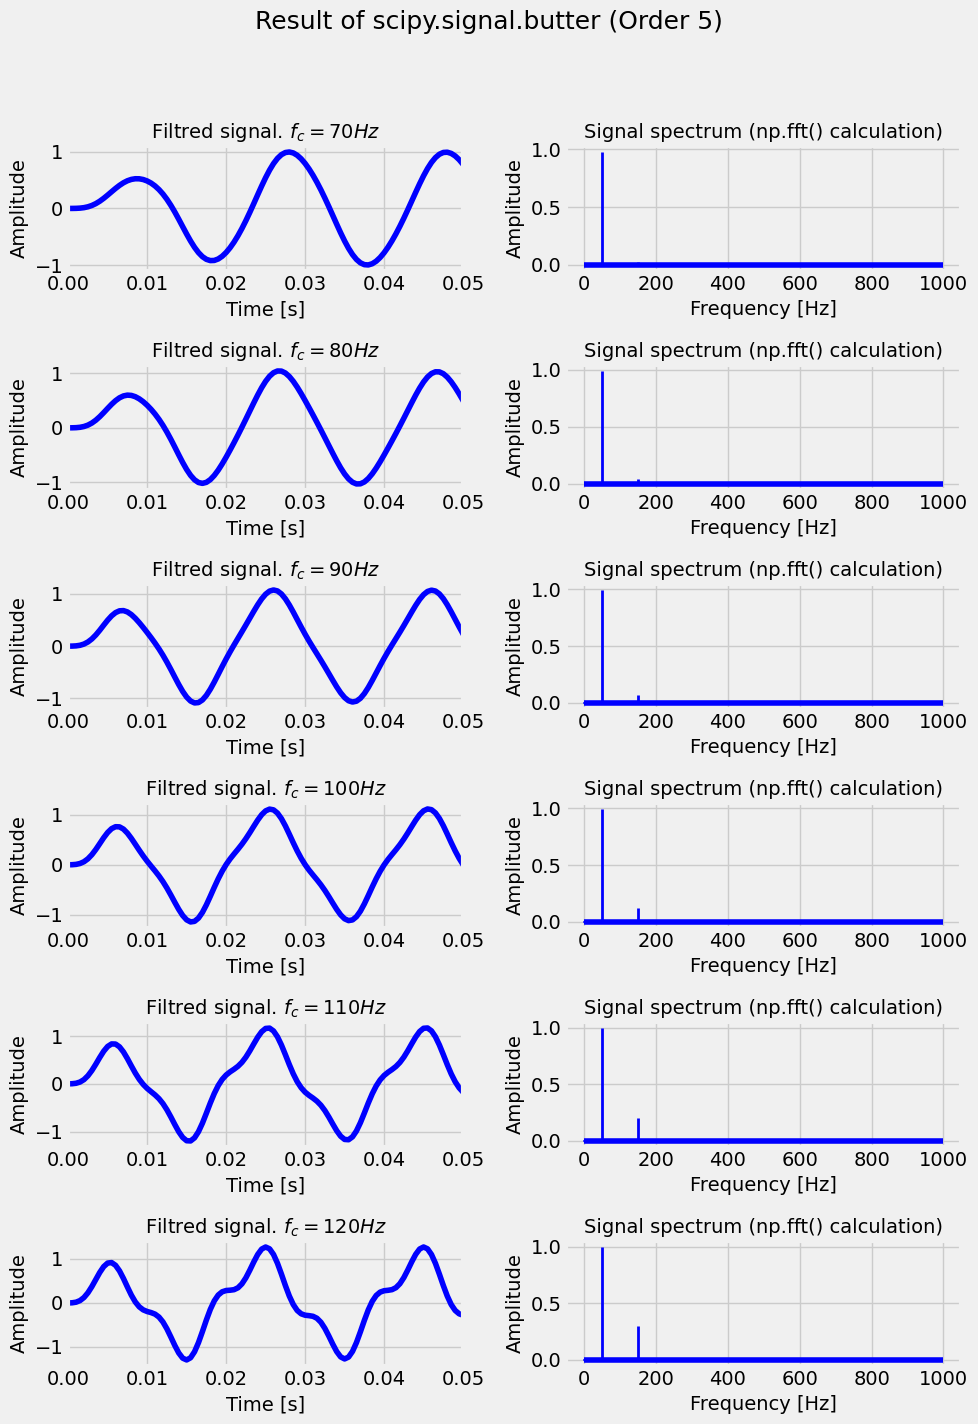

In [28]:
from scipy import signal

plt.figure(figsize=(10, 2.5 * numb_filter))
plt.suptitle(f'Result of scipy.signal.butter (Order 5)', fontsize=18)

for i in range(numb_filter):
    b, a = signal.butter(5, fc[i], btype='low', fs=Fs)

    filtered_signal = signal.lfilter(b, a, signal_vals)

    filtered_spectrum = np.fft.fft(filtered_signal)
    N = len(filtered_signal)

    plt.subplot(numb_filter, 2, 2 * i + 1)
    plt.plot(t_vals, filtered_signal, 'b')
    plt.title(f'Filtred signal. $f_c ={fc[i]} Hz$', fontsize=14)
    plt.xlabel('Time [s]', fontsize=14)
    plt.xlim(0, 0.05)
    plt.ylabel('Amplitude', fontsize=14)

    plt.subplot(numb_filter, 2, 2 * i + 2)
    markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(filtered_spectrum[:N//2]))

    plt.setp(stemlines, color='blue', linewidth=2) 
    plt.setp(markerline, color='red', markersize=0)
    plt.setp(baseline, color='blue')

    plt.title('Signal spectrum (np.fft() calculation)', fontsize=14)
    plt.xlabel('Frequency [Hz]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.tight_layout()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## <a id='toc1_8_'></a>[Task8](#toc0_)
Добавьте случайный шум к исходному сигналу и проанализируйте, как происходит процесс фильтрации для зашумленного сигнала.

In [29]:
signal_vals_noise = signal_vals + np.random.normal(0, 1, N)

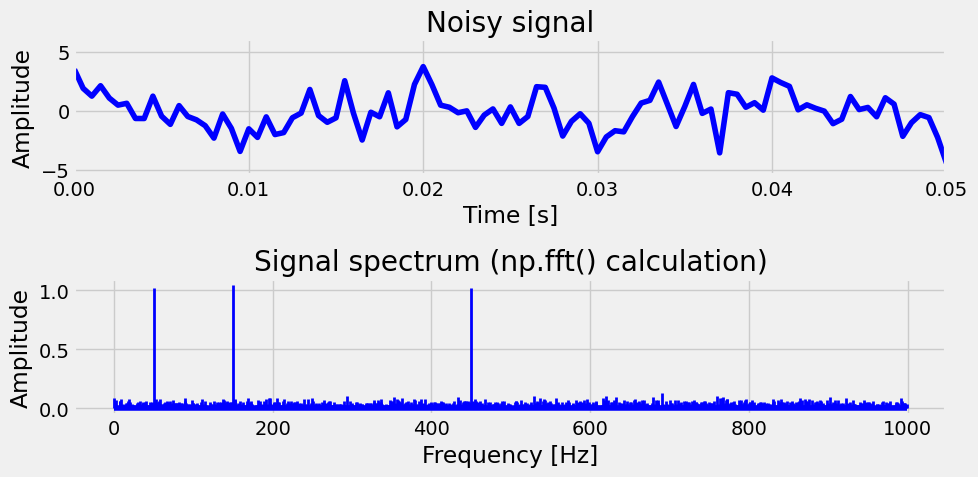

In [30]:
np.random.seed(42)

signal_vals_noise = signal_vals + np.random.normal(0, 1, N)

spectrum_noisy_fft = np.fft.fft(signal_vals_noise)

N = signal_vals_noise.shape[-1]

freq = np.fft.fftfreq(N, dt)

plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
plt.plot(t_vals, signal_vals_noise, 'b')
plt.title('Noisy signal')
plt.xlabel('Time [s]')
plt.xlim(0, 0.05)
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(spectrum_noisy_fft[:N//2]))

plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Signal spectrum (np.fft() calculation)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

In [31]:
fc = np.arange(70,121,10)
wc = 2 * np.pi * fc
numb_filter = fc.shape[0]

w = freq.copy() * 2 * np.pi

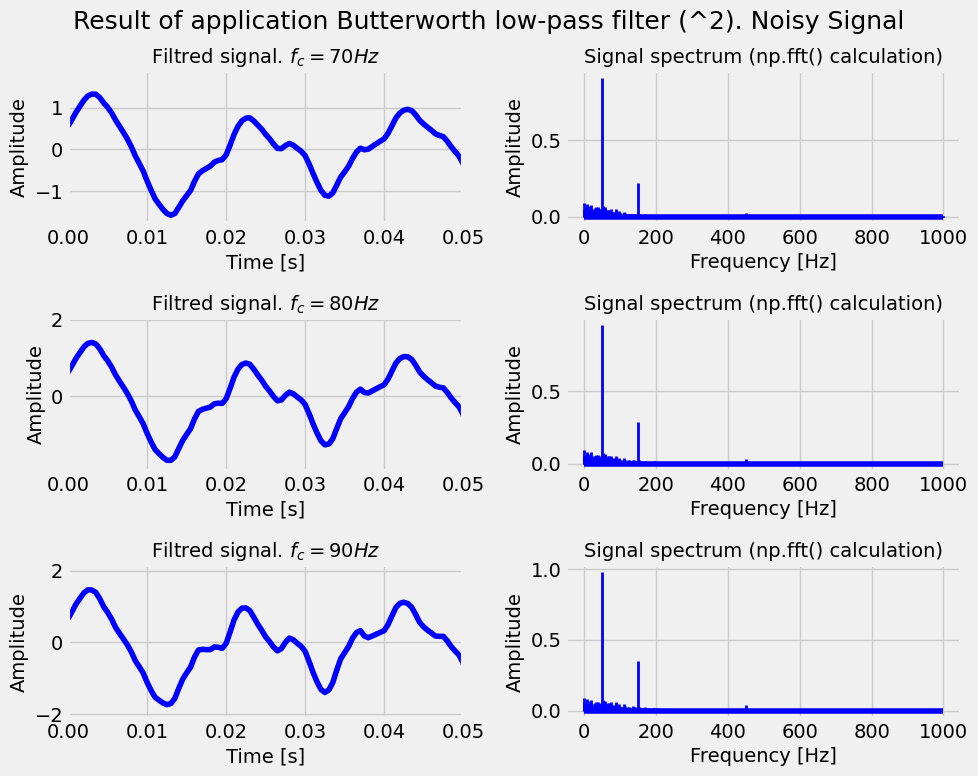

In [32]:
plt.figure(figsize=(10, 2.5 * numb_filter))
plt.suptitle('Result of application Butterworth low-pass filter (^2). Noisy Signal', fontsize=18)

for i in range (numb_filter - 3):
    H =  (wc[i]**2) / (-(w**2) + 1j * np.sqrt(2) * wc[i] * w + wc[i]**2)
    
    filtered_spectrum = H * spectrum_noisy_fft
    N = filtered_spectrum.shape[0]

    filtered_signal = np.fft.ifft(filtered_spectrum).real

    plt.subplot(numb_filter, 2, 2 * i + 1)
    plt.plot(t_vals, filtered_signal, 'b')
    plt.title(f'Filtred signal. $f_c ={fc[i]} Hz$', fontsize=14)
    plt.xlabel('Time [s]', fontsize=14)
    plt.xlim(0, 0.05)
    plt.ylabel('Amplitude', fontsize=14)

    plt.subplot(numb_filter, 2, 2 * i + 2)
    markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(filtered_spectrum[:N//2]))

    plt.setp(stemlines, color='blue', linewidth=2) 
    plt.setp(markerline, color='red', markersize=0)
    plt.setp(baseline, color='blue')

    plt.title('Signal spectrum (np.fft() calculation)', fontsize=14)
    plt.xlabel('Frequency [Hz]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.tight_layout()
plt.show()

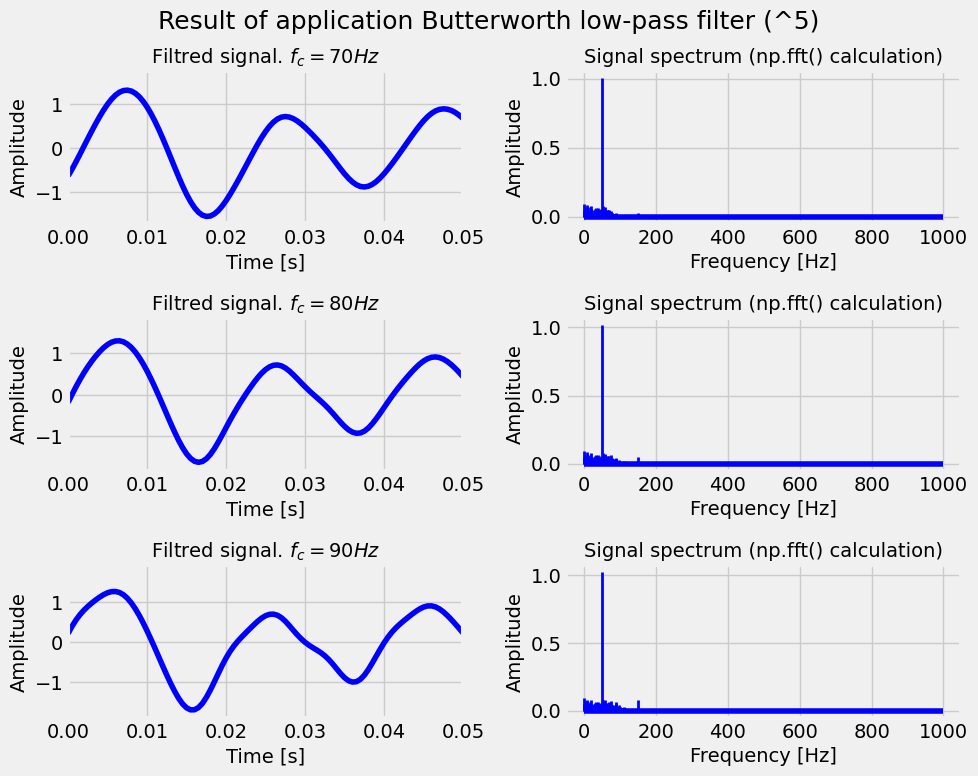

In [33]:
plt.figure(figsize=(10, 2.5 * numb_filter))
plt.suptitle('Result of application Butterworth low-pass filter (^5)', fontsize=18)

for i in range (numb_filter - 3):
    filtered_spectrum = H_5[i] * spectrum_noisy_fft
    N = filtered_spectrum.shape[0]

    filtered_signal = np.fft.ifft(filtered_spectrum).real

    plt.subplot(numb_filter, 2, 2 * i + 1)
    plt.plot(t_vals, filtered_signal, 'b')
    plt.title(f'Filtred signal. $f_c ={fc[i]} Hz$', fontsize=14)
    plt.xlabel('Time [s]', fontsize=14)
    plt.xlim(0, 0.05)
    plt.ylabel('Amplitude', fontsize=14)

    plt.subplot(numb_filter, 2, 2 * i + 2)
    markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(filtered_spectrum[:N//2]))

    plt.setp(stemlines, color='blue', linewidth=2) 
    plt.setp(markerline, color='red', markersize=0)
    plt.setp(baseline, color='blue')

    plt.title('Signal spectrum (np.fft() calculation)', fontsize=14)
    plt.xlabel('Frequency [Hz]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.tight_layout()
plt.show()

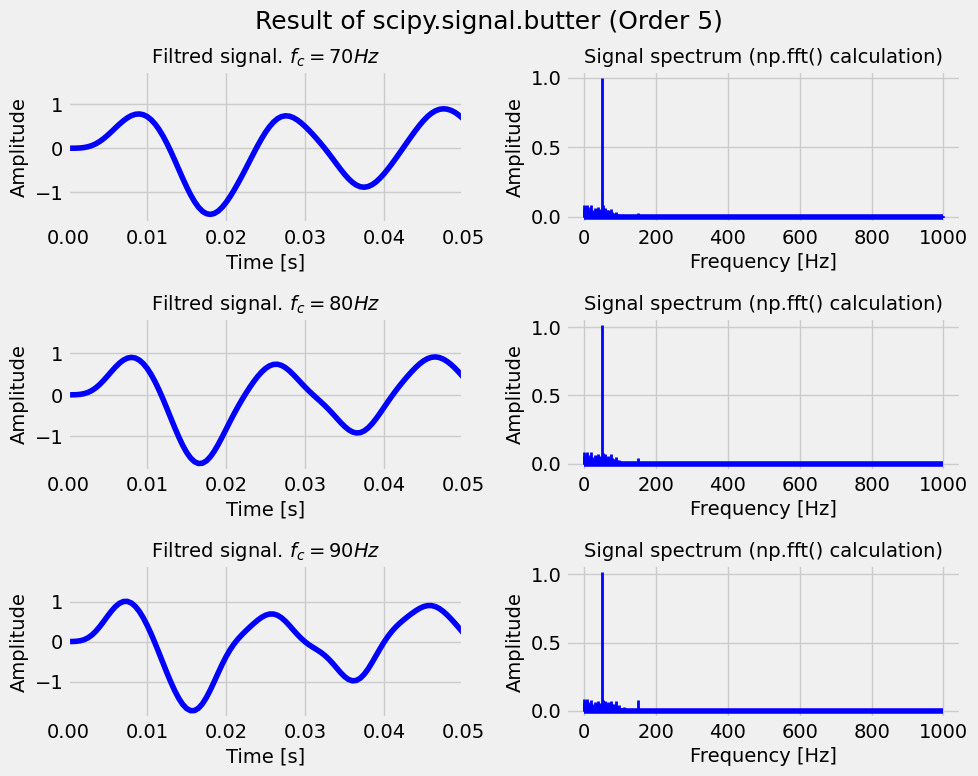

In [34]:
from scipy import signal

plt.figure(figsize=(10, 2.5 * numb_filter))
plt.suptitle(f'Result of scipy.signal.butter (Order 5)', fontsize=18)

for i in range(numb_filter - 3):
    b, a = signal.butter(5, fc[i], btype='low', fs=Fs)

    filtered_signal = signal.lfilter(b, a, signal_vals_noise)

    filtered_spectrum = np.fft.fft(filtered_signal)
    N = len(filtered_signal)

    plt.subplot(numb_filter, 2, 2 * i + 1)
    plt.plot(t_vals, filtered_signal, 'b')
    plt.title(f'Filtred signal. $f_c ={fc[i]} Hz$', fontsize=14)
    plt.xlabel('Time [s]', fontsize=14)
    plt.xlim(0, 0.05)
    plt.ylabel('Amplitude', fontsize=14)

    plt.subplot(numb_filter, 2, 2 * i + 2)
    markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(filtered_spectrum[:N//2]))

    plt.setp(stemlines, color='blue', linewidth=2) 
    plt.setp(markerline, color='red', markersize=0)
    plt.setp(baseline, color='blue')

    plt.title('Signal spectrum (np.fft() calculation)', fontsize=14)
    plt.xlabel('Frequency [Hz]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.tight_layout()
plt.show()

## <a id='toc1_9_'></a>[Task9](#toc0_)
Реализуйте фильтр ФНЧ Чебышева 1-го рода N-порядка.

In [35]:
fc = np.arange(70,121,10)
wc = 2 * np.pi * fc
numb_filter = fc.shape[0]

w = freq.copy() * 2 * np.pi

In [36]:
def T_n_Chebi(w, n):

    if n == 0: return 1

    if n == 1: return w

    return 2 * w * T_n_Chebi(w, n-1) - T_n_Chebi(w, n-2)

In [40]:
N_Chebi = 5
eps = 0.5

In [41]:
all_T = [T_n_Chebi(w/wp, N_Chebi) for wp in wc]

In [46]:
H = [1 / np.sqrt(1 + eps**2 * T**2) for T in all_T]

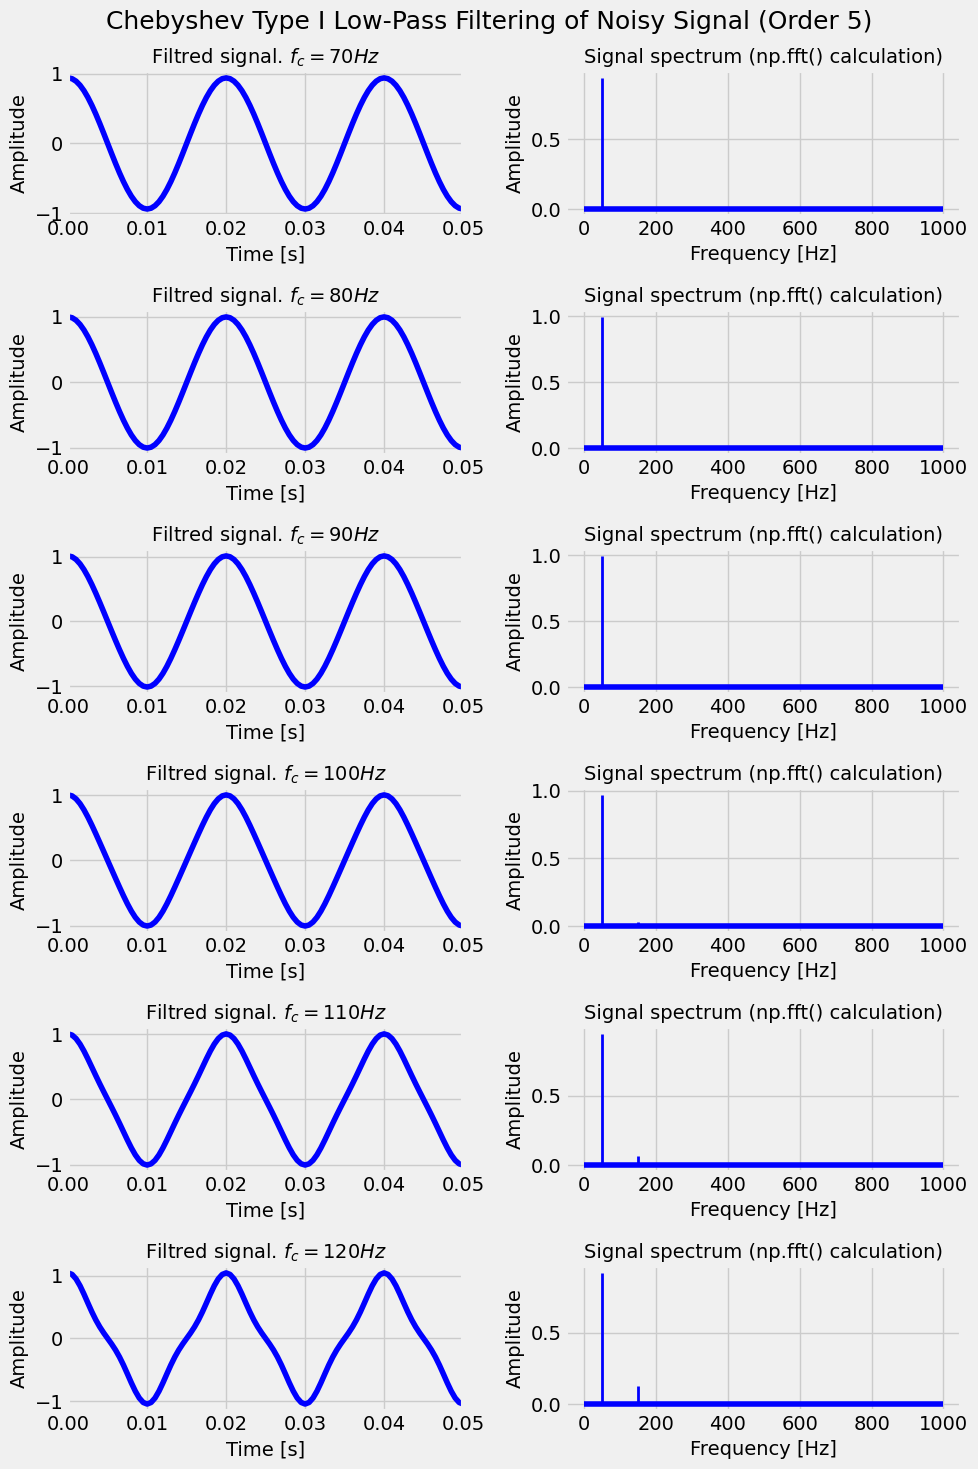

In [47]:
from scipy import signal

plt.figure(figsize=(10, 2.5 * numb_filter))
plt.suptitle('Chebyshev Type I Low-Pass Filtering of Noisy Signal (Order 5)', fontsize=18)

for i in range(numb_filter):
    
    filtered_spectrum = H[i] * spectrum_fft
    N = filtered_spectrum.shape[0]
    filtered_signal = np.fft.ifft(filtered_spectrum).real

    N = len(filtered_signal)

    plt.subplot(numb_filter, 2, 2 * i + 1)
    plt.plot(t_vals, filtered_signal, 'b')
    plt.title(f'Filtred signal. $f_c ={fc[i]} Hz$', fontsize=14)
    plt.xlabel('Time [s]', fontsize=14)
    plt.xlim(0, 0.05)
    plt.ylabel('Amplitude', fontsize=14)

    plt.subplot(numb_filter, 2, 2 * i + 2)
    markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(filtered_spectrum[:N//2]))

    plt.setp(stemlines, color='blue', linewidth=2) 
    plt.setp(markerline, color='red', markersize=0)
    plt.setp(baseline, color='blue')

    plt.title('Signal spectrum (np.fft() calculation)', fontsize=14)
    plt.xlabel('Frequency [Hz]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.tight_layout()
plt.show()